# Prática Guiada: Prevendo o Custo de um Plano de Saúde

**Pós-graduação PUC Minas | Machine Learning | Encontro 2**

Nesta prática vocês vão treinar sozinhos os modelos de regressão que vimos na aula teórica, usando uma base de dados real e mais simples do que a da aula anterior: custos de plano de saúde nos Estados Unidos, com idade, sexo, IMC, número de filhos e se a pessoa é fumante.

**Como funciona esta prática:**

- As primeiras etapas (carregar os dados, explorar, preparar) já vêm prontas, exatamente como fizemos juntos na aula anterior. Rodem essas células para seguir em frente.
- A partir da etapa de treinar os modelos, é a vez de vocês. Cada exercício traz um passo a passo em texto e uma célula de código com trechos marcados `# COMPLETE AQUI`, onde vocês escrevem o código.
- Sempre que precisarem, tem uma dica logo abaixo do exercício.

**Objetivo**: prever a coluna `charges` (custo do plano de saúde, em dólares) a partir das demais colunas.

**Antes de começar**: baixem o arquivo `custo_medico.csv` e deixem na mesma pasta deste notebook.

## 0. Preparando o Ambiente

Como sempre, começamos importando as bibliotecas que vamos usar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

---

## Etapa 1: Carregando e Conhecendo os Dados

Esta etapa já vem pronta, é a mesma sequência que fizemos juntos na aula anterior: carregar, olhar o formato, os tipos de cada coluna e checar valores faltando.

In [2]:
# USEI LOCAL POIS ESTOU RODANDO LOCAL, NAO NO COLAB
caminho_arquivo = '../dataset/custo_medico.csv'
dados = pd.read_csv(caminho_arquivo)
dados.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
dados = pd.read_csv('../dataset/custo_medico.csv')
dados.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(f'Formato dos dados: {dados.shape[0]} linhas, {dados.shape[1]} colunas')
dados.info()

Formato dos dados: 1338 linhas, 7 colunas
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
dados.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Boa notícia: esta base não tem nenhum valor faltando, então não precisamos repetir o `dropna()` que fizemos na aula anterior. Vamos direto para conhecer melhor os dados.

In [6]:
dados.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


---

## Etapa 2: Explorando os Dados

Antes de treinar qualquer modelo, vale a pena olhar como a variável que queremos prever (`charges`) se comporta.

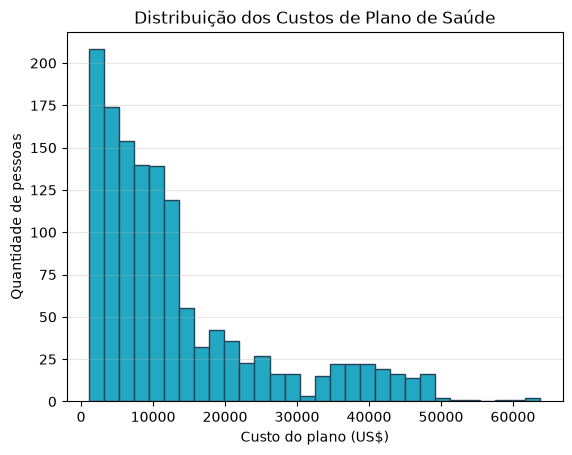

In [7]:
plt.hist(dados['charges'], bins=30, color='#23A8C3', edgecolor='#244357')
plt.xlabel('Custo do plano (US$)')
plt.ylabel('Quantidade de pessoas')
plt.title('Distribuição dos Custos de Plano de Saúde')
plt.grid(alpha=0.3, axis='y')
plt.show()

A distribuição é bem assimétrica: a maioria das pessoas tem custo baixo, mas existe uma cauda de custos bem altos. Vamos ver se `smoker` (fumante) ajuda a explicar essa cauda.

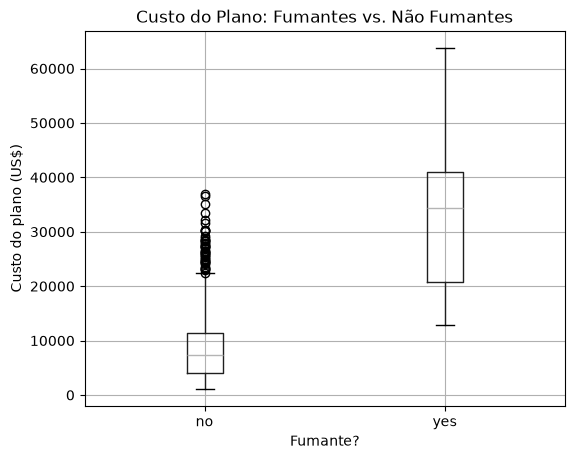

In [8]:
dados.boxplot(column='charges', by='smoker', figsize=(6, 5))
plt.suptitle('')
plt.title('Custo do Plano: Fumantes vs. Não Fumantes')
plt.xlabel('Fumante?')
plt.ylabel('Custo do plano (US$)')
plt.show()

A diferença é enorme: fumantes custam, em média, quase 4 vezes mais do que não fumantes. É bem provável que `smoker` seja a variável mais importante do nosso modelo, vamos confirmar isso mais adiante com a importância de features.

---

## Etapa 3: Preparando os Dados

Os modelos de Machine Learning só entendem números, mas temos três colunas de texto: `sex`, `smoker` e `region`. Esta etapa também já vem pronta.

Para `sex` e `smoker`, que só têm duas opções cada, basta trocar por 0 e 1. Para `region`, que tem quatro opções, usamos `pd.get_dummies`, que cria uma coluna binária para cada região.

In [9]:
dados_prontos = dados.copy()

dados_prontos['sex'] = dados_prontos['sex'].map({'female': 0, 'male': 1})
dados_prontos['smoker'] = dados_prontos['smoker'].map({'no': 0, 'yes': 1})

dados_prontos = pd.get_dummies(dados_prontos, columns=['region'], drop_first=True)

dados_prontos.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [10]:
X = dados_prontos.drop(columns=['charges'])
y = dados_prontos['charges']

print('Features usadas:', list(X.columns))

Features usadas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


---

## Etapa 4: Separando Treino e Teste

Mesmo processo de sempre: uma parte dos dados para o modelo aprender, outra para testarmos de forma justa, sem o modelo ter visto essas pessoas antes.

In [11]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Exemplos de treino: {len(X_treino)}')
print(f'Exemplos de teste: {len(X_teste)}')

Exemplos de treino: 1070
Exemplos de teste: 268


Daqui em diante, é com vocês. Cada exercício segue sempre o mesmo padrão que vimos na aula teórica: criar o modelo, treinar com `.fit(...)`, prever com `.predict(...)` e avaliar com as métricas de erro.

---

## Etapa 5, Exercício 1: Regressão Linear

Vamos treinar o modelo mais simples primeiro. Sigam os passos abaixo e completem o código na célula seguinte, nos trechos marcados `# COMPLETE AQUI`.

**Passo a passo:**

1. Crie um dicionário vazio chamado `resultados`, vamos usá-lo para guardar as métricas de cada modelo e comparar todos no final.
2. Crie o modelo de Regressão Linear com `LinearRegression()` e guarde em uma variável chamada `modelo_linear`.
3. Treine o modelo chamando `.fit(X_treino, y_treino)`.
4. Use `.predict(X_teste)` para gerar as previsões no conjunto de teste, e guarde em `y_previsto_linear`.
5. Calcule o MAE, o RMSE e o R² comparando `y_teste` com `y_previsto_linear`. Lembrem-se: RMSE é a raiz quadrada do MSE.
6. Imprima as três métricas.
7. Guarde os resultados em `resultados['Regressão Linear']`, seguindo o mesmo formato que vimos em aula: um dicionário com as chaves `'MAE'`, `'RMSE'` e `'R2'`.

In [12]:
resultados = {}

# 1. Crie o modelo de Regressão Linear
modelo_linear = LinearRegression()

# 2. Treine o modelo com os dados de treino
modelo_linear.fit(X_treino, y_treino)

# 3. Faça as previsões no conjunto de teste
y_previsto_linear = modelo_linear.predict(X_teste)

# 4. Calcule as métricas de erro
mae_linear = mean_absolute_error(y_teste, y_previsto_linear)
rmse_linear =np.sqrt(mean_squared_error(y_teste, y_previsto_linear))
r2_linear =  r2_score(y_teste, y_previsto_linear)

print(f'MAE  = US$ {mae_linear:,.2f}')
print(f'RMSE = US$ {rmse_linear:,.2f}')
print(f'R2   = {r2_linear:.2f}')

# 5. Guarde os resultados no dicionário resultados
resultados['Regressão Linear'] = {'MAE': mae_linear, 'RMSE': rmse_linear, 'R2': r2_linear}

MAE  = US$ 4,181.19
RMSE = US$ 5,796.28
R2   = 0.78


💡 **Dica, caso fiquem travados:** o modelo se cria só com `LinearRegression()`, sem nenhum parâmetro. As funções de métrica são `mean_absolute_error(y_real, y_previsto)`, `mean_squared_error(y_real, y_previsto)` (para o RMSE, usem `np.sqrt(...)` em cima do resultado) e `r2_score(y_real, y_previsto)`. Todas elas recebem primeiro o valor real, depois o valor previsto.

---

## Etapa 6, Exercício 2: Árvore de Decisão

Agora repitam o mesmo processo do Exercício 1, mas usando uma Árvore de Decisão em vez de Regressão Linear. O padrão é sempre o mesmo: criar, treinar, prever, avaliar, guardar.

**Passo a passo:**

1. Crie o modelo com `DecisionTreeRegressor(max_depth=5, random_state=42)` e guarde em `modelo_arvore`. Usamos `max_depth=5` para começar, sintam-se à vontade para testar outros valores depois.
2. Treine o modelo.
3. Faça as previsões no conjunto de teste e guarde em `y_previsto_arvore`.
4. Calcule MAE, RMSE e R².
5. Imprima as métricas.
6. Guarde os resultados em `resultados['Árvore de Decisão']`.

In [13]:
# 1. Crie o modelo de Árvore de Decisão
modelo_arvore = DecisionTreeRegressor(max_depth=5, random_state=42)

# 2. Treine o modelo
modelo_arvore.fit(X_treino, y_treino)

# 3. Faça as previsões no conjunto de teste
y_previsto_arvore = modelo_arvore.predict(X_teste)

# 4. Calcule as métricas de erro
mae_arvore = mean_absolute_error(y_teste, y_previsto_arvore)
rmse_arvore = np.sqrt(mean_squared_error(y_teste, y_previsto_arvore))
r2_arvore = r2_score(y_teste, y_previsto_arvore)

print(f'MAE  = US$ {mae_arvore:,.2f}')
print(f'RMSE = US$ {rmse_arvore:,.2f}')
print(f'R2   = {r2_arvore:.2f}')

# 5. Guarde os resultados no dicionário resultados
resultados['Árvore de Decisão'] = {'MAE': mae_arvore, 'RMSE': rmse_arvore, 'R2': r2_arvore}

MAE  = US$ 2,930.77
RMSE = US$ 5,082.51
R2   = 0.83


💡 **Dica:** repare que este exercício pede exatamente os mesmos passos do Exercício 1, só muda a primeira linha (o modelo criado) e os nomes das variáveis. Se o Exercício 1 funcionou, é só seguir o mesmo padrão aqui.

**Pergunta para pensar:** o R² da Árvore de Decisão foi maior, menor ou igual ao da Regressão Linear? Faz sentido com o que vimos na aula teórica sobre cada um desses modelos?

## RESPOSTA:

O R2 da árvore foi maior, casando com o que foi dito na teoria. Isos faz sentido pois o custo não crece em linha reta, pois o smoker= true muda completamente a interpretação dos dados em 2 grupos separados. Também é possivel ver que alguns fatores são mais efetivos  entre os fumantes. E sobre o MAE, a árvore erra menos no geral pois divide melhor os dados.

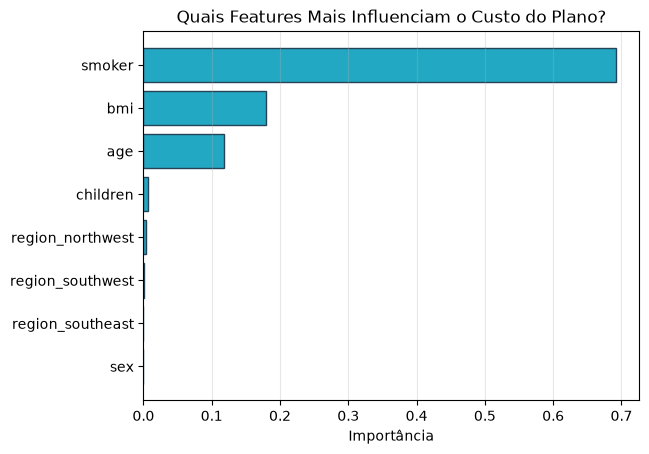

In [14]:
importancias = pd.Series(modelo_arvore.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.barh(importancias.index, importancias.values, color='#23A8C3', edgecolor='#244357')
plt.xlabel('Importância')
plt.title('Quais Features Mais Influenciam o Custo do Plano?')
plt.grid(alpha=0.3, axis='x')
plt.show()

Confirma a intuição que tivemos no boxplot lá na Etapa 2: `smoker` costuma aparecer como a feature mais importante, de longe.

---

## Etapa 7, Desafio: Random Forest

Este último é por sua conta, sem scaffold de código, só o passo a passo. Se travarem, voltem aos dois exercícios anteriores: o padrão é sempre o mesmo, só muda o modelo.

**Passo a passo:**

1. Crie o modelo com `RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)`.
2. Treine o modelo.
3. Faça as previsões no conjunto de teste.
4. Calcule MAE, RMSE e R².
5. Imprima as métricas.
6. Guarde os resultados em `resultados['Random Forest']`.

Escrevam o código do zero na célula abaixo.

In [15]:
modelo_floresta = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)

modelo_floresta.fit(X_treino, y_treino)

y_previsto_floresta = modelo_floresta.predict(X_teste)

mae_floresta = mean_absolute_error(y_teste, y_previsto_floresta)
rmse_floresta = np.sqrt(mean_squared_error(y_teste, y_previsto_floresta))
r2_floresta = r2_score(y_teste, y_previsto_floresta)

print(f'MAE  = US$ {mae_floresta:,.2f}')
print(f'RMSE = US$ {rmse_floresta:,.2f}')
print(f'R2   = {r2_floresta:.2f}')

resultados['Random Forest'] = {'MAE': mae_floresta, 'RMSE': rmse_floresta, 'R2': r2_floresta}

MAE  = US$ 2,467.59
RMSE = US$ 4,491.00
R2   = 0.87


---

## Comparação Final

Esta última parte já vem pronta. Ela lê o dicionário `resultados` que vocês foram preenchendo em cada exercício e monta a tabela e o gráfico de comparação, exatamente como fizemos na aula anterior.

Se algum exercício não foi completado, ele simplesmente não aparece aqui, então voltem e completem todos antes de rodar esta parte.

In [16]:
tabela_resultados = pd.DataFrame(resultados).T
tabela_resultados = tabela_resultados.sort_values('R2', ascending=False)
tabela_resultados

,MAE,RMSE,R2
Random Forest,2467.594403,4491.000896,0.870085
Árvore de Decisão,2930.767571,5082.505544,0.833610
Regressão Linear,4181.194474,5796.284659,0.783593


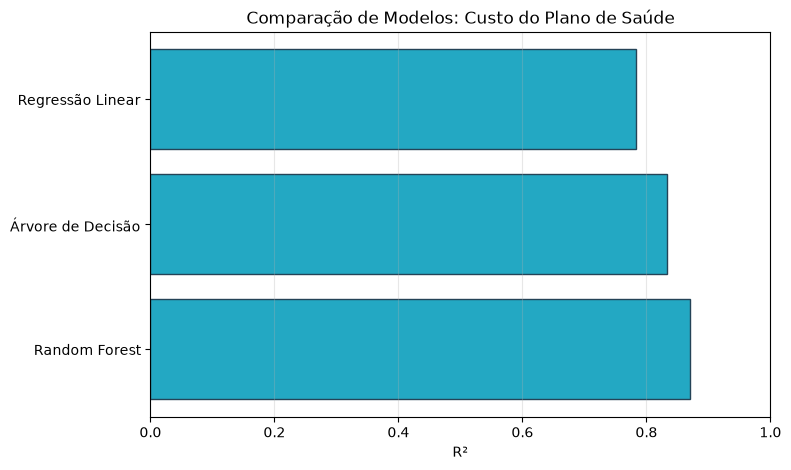

In [17]:
plt.figure(figsize=(8, 5))
plt.barh(tabela_resultados.index, tabela_resultados['R2'], color='#23A8C3', edgecolor='#244357')
plt.xlabel('R²')
plt.title('Comparação de Modelos: Custo do Plano de Saúde')
plt.xlim(0, 1)
plt.grid(alpha=0.3, axis='x')
plt.show()

**Para refletir:**

1. Qual modelo teve o melhor R²? O resultado te surpreendeu?
2. O MAE está em dólares, o que significa, na prática, um MAE de alguns milhares de dólares para prever o custo de um plano de saúde?
3. Desafio extra: tente `max_depth=3` e `max_depth=15` na Árvore de Decisão e no Random Forest. O que acontece com o R² no teste em cada caso? Isso tem a ver com o que vimos sobre overfitting na aula teórica?
4. Desafio extra: remova a coluna `smoker` de `X` e treine os modelos de novo. O quanto o R² piora? Isso mostra a importância dessa única variável.

In [18]:
resultados_profundidade = []
for profundidade in [3, 15]:
    modelos_profundidade = {
        'Árvore de Decisão': DecisionTreeRegressor(max_depth=profundidade, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=profundidade, random_state=42),
    }
    for nome, modelo in modelos_profundidade.items():
        modelo.fit(X_treino, y_treino)
        resultados_profundidade.append({
            'Modelo': nome,
            'max_depth': profundidade,
            'R2 treino': r2_score(y_treino, modelo.predict(X_treino)),
            'R2 teste': r2_score(y_teste, modelo.predict(X_teste)),
        })

pd.DataFrame(resultados_profundidade).sort_values(['Modelo', 'max_depth']).round(2)

,Modelo,max_depth,R2 treino,R2 teste
1,Random Forest,3,0.86,0.87
3,Random Forest,15,0.97,0.86
0,Árvore de Decisão,3,0.85,0.85
2,Árvore de Decisão,15,1.00,0.71


In [19]:
X_treino_sem_smoker = X_treino.drop(columns=['smoker'])
X_teste_sem_smoker = X_teste.drop(columns=['smoker'])

modelos_sem_smoker = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
}

resultados_sem_smoker = {}
for nome, modelo in modelos_sem_smoker.items():
    modelo.fit(X_treino_sem_smoker, y_treino)
    y_previsto = modelo.predict(X_teste_sem_smoker)
    resultados_sem_smoker[nome] = {
        'R2 com smoker': resultados[nome]['R2'],
        'R2 sem smoker': r2_score(y_teste, y_previsto),
        'MAE sem smoker': mean_absolute_error(y_teste, y_previsto),
    }

pd.DataFrame(resultados_sem_smoker).T.round(2)

,R2 com smoker,R2 sem smoker,MAE sem smoker
Regressão Linear,0.78,0.16,9066.51
Árvore de Decisão,0.83,0.09,9326.82
Random Forest,0.87,0.10,9273.93


**Respostas:**

1. random forest, nao me surpeendeu, pois me parece ser o modelo que enxerga mais coisas em consideração pra esse dataset. Por ter muitas arvores
2. Em quantos dolares o modelo erra por pessoa na análise que ele fez. Se for parar pra pensar 2500$ de erro é bastante dinheiro.
3. A árvore começou a decorar coisas do treino e começou a aumentar o overfitting. Já a random forest não deu tanta diferenca pois são muitas árvores e elas se ajustam
4. Sem o smoker, o desempenho do modelo piorou muito. Pois é uma variável com uma relação muito grande com a leitura. O r2 foi pra perto de 0.1 nos modelos, aumentando a variancia do erro em 9k dolar